<h1 align="center">~Treći domaći zadatak~</h1> 
<h2 align="center">Digitalna obrada slike (13E044DOS)</h2> 
<h3 align="left">Student: Magdalena Savić</h3> 
<h3 align="left">Broj indeksa: 2022/0351</h3> 

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import skimage as ski
from skimage import io, color, util, filters, morphology
import matplotlib.pyplot as plt
import scipy.ndimage as ndi    
from collections import deque
import os
import pandas as pd

data_dir = "../sekvence/"

### Prvi dio

U ovom zadatku se od nas traži da na zadatim slikama uradimo robusnu segmentaciju novčića, prebrojimo ih i odredimo koliko ima malih ($1$ dinar) i velikih ($5$ dinara) novčića.

Problem detekcije novčića na slici podrazumijeva segmentaciju objekata od interesa (novčića) od pozadine. Analizom ulaznih slika uočeno je da novčići imaju karakterističnu boju (srebrna/zlatna/bakarna) koja se razlikuje od zelene podloge, kao i izraženu teksturu (reljef) u odnosu na glatku podlogu. Međutim, osvjetljaj je neuniforman, a prisutan je i odsjaj.

Zbog toga je implementiran hibridni pristup segmentaciji koji kombinuje informacije o boji i teksturi, a zatim koristi automatsko određivanje pragova (Otsu metodu).

#### Funkcija `coin_mask` - segmentacija novčića

Segmentacija se zasniva na kombinaciji dva pristupa: analize boje u HSV prostoru i analize teksture putem lokalne standardne devijacije. Ideja je da svaki pristup sam po sebi ima slabosti, ali njihovom kombinacijom se dobija robusna maska.
- **Medijan filtriranje**: Ulazna slika se prvo blago filtrira medijan filtrom veličine $3×3$ po svakom kanalu. Ovo smanjuje impulsni šum bez značajnog gubitka ivica, što je bitno jer ogrebotine na podlozi mogu generisati lažne detekcije.
- **Konverzija u HSV kolor sistem**: RGB slika se konvertuje u HSV kolor sistem. Hue ($H$) komponenta nosi informaciju o tonu boje nezavisno od osvjetljenja, što je ključno jer se novčići fotografišu pod različitim uslovima. Saturacija ($S$) razdvaja hromatske od ahromatskih regiona.
- **Adaptivna detekcija pozadine**: Polazi se od pretpostavke da pozadina zauzima najveći dio slike, pa dominantan hue u histogramu odgovara pozadini. Histogram hue vrijednosti se računa sa 180 binova, a svi binovi koji imaju bar 20% piksela dominantnog bina smatraju se dijelom pozadine. Opseg se dodatno ograničava npr. ako je širi od 0.4 sužava se na $±0.12$ oko dominantnog hue-a, a ako je uži od $0.06$ proširuje se na $±0.06$. Za prag saturacije koristi se Otsu metod primijenjen na saturaciju pozadinskih piksela, pomnožen sa $0.5$ (sa donjim ograničenjem od $0.08$). Sve što ne pripada pozadini po hue-u i saturaciji smatra se kandidatom za novčić.
- **Analiza teksture**: Lokalna standardna devijacija se računa u prozoru čija veličina zavisi od dimenzije slike ($0.5\%$ manje dimenzije). Pikseli sa standardnom devijacijom iznad $30\%$ Otsu praga smatraju se teksturiranim. Ključna ideja je da novčići imaju teksturu na svojim ivicama (reljef, natpisi), dok glatka pozadina nema. Maska teksture se zatim dilatira diskom poluprečnika $2.5\%$ manje dimenzije slike. Dilatacija širi teksturu sa ivica novčića ka njihovom centru, čak iako je centar novčića gladak, on je u blizini teksturirane ivice, pa ga dilatacija pokriva. Istovremeno, artefakti pozadine koji su daleko od bilo kakve teksture ostaju nepokriveni.
- **Kombinovanje maski**: Finalna maska je logička $AND$ kombinacija maske boje i dilatirane teksture. Piksel mora zadovoljiti oba uslova: da nije pozadina po boji i da se u njegovoj okolini nalazi tekstura. Ovim se eliminišu kako artefakti boje (ogrebotine na podlozi koje imaju drugačiji hue ali nemaju teksturu) tako i artefakti teksture (šumoviti regioni koji imaju teksturu ali su iste boje kao pozadina).
- **Morfološko čišćenje**: Na kombinovanu masku se primjenjuju redom: otvaranje (uklanja male fragmente šuma), popunjavanje rupa (zatvara rupe unutar novčića), zatvaranje (popunjava male prekide na ivicama) i ponovo popunjavanje rupa. Veličine strukturnih elemenata su skalirane prema dimenziji slike — disk za otvaranje je $0.4\%$ manje dimenzije, a za zatvaranje $0.5\%$. Ovo čini algoritam nezavisnim od rezolucije ulazne slike.
- **Uklanjanje ivičnih regiona**: Na kraju se brišu svi regioni koji dodiruju ivicu slike. Novčići su uvek cijeli na slici, pa svaki region koji dodiruje rub sigurno nije novčić, to mogu na primjer da budu dijelovi drugih objekata vidljivi na periferiji (npr. ivica stola).

In [3]:
def coin_mask(img_in, verbose=False, return_steps=False):
    # segmentacija novcica - vraca binarnu masku (1=novcic, 0=pozadina)

    # konverzija formata slike
    if img_in.dtype == np.uint8:
        img = util.img_as_float(img_in)
    else:
        img = img_in.copy()

    rows, cols = img.shape[:2]
    min_dim = min(rows, cols)

    # definisanje strukturnih elemenata relativno u odnosu na velicinu slike
    disk_small = max(2, int(round(min_dim * 0.004)))
    disk_close = max(3, int(round(min_dim * 0.005)))

    # potiskujemo sum prije filtriranja
    # koristimo medijan filtar da sacuvamo ivice, a uklonimo impulsni sum
    img_smooth = np.stack([
        ndi.median_filter(img[:, :, c], size=3) for c in range(3)
    ], axis=2)

    # konverzija u hsv prostor radi odvajanja hrominanse i osvjetljaja
    hsv = color.rgb2hsv(img_smooth)
    H, S, V = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]

    # radi se analiza boja (segmentacija bazirana na regionima)
    # analiza histograma h kanala kako bi se detektovala dominantna pozadina
    saturated = S > 0.10
    if np.sum(saturated) < 0.1 * rows * cols:
        saturated = np.ones_like(S, dtype=bool)

    hue_values = H[saturated]
    # formiranje histograma hue kanala
    hist, bin_edges = np.histogram(hue_values, bins=180, range=(0, 1))
    dominant_bin = np.argmax(hist) # dominantni bin (zelena pozadina)
    dominant_hue = (bin_edges[dominant_bin] + bin_edges[dominant_bin + 1]) / 2.0

    # odredjivanje sirine opsega oko dominantnog bina
    threshold_count = 0.20 * hist[dominant_bin]
    bg_bins = hist > threshold_count
    bg_bin_indices = np.where(bg_bins)[0]

    hue_min = bin_edges[bg_bin_indices[0]]
    hue_max = bin_edges[bg_bin_indices[-1] + 1]

    # heuristika za stabilizaciju opsega boje
    hue_range = hue_max - hue_min
    if hue_range > 0.4:
        hue_min = dominant_hue - 0.12
        hue_max = dominant_hue + 0.12
    elif hue_range < 0.06:
        hue_min = dominant_hue - 0.06
        hue_max = dominant_hue + 0.06

    # primjena Otsu metode na saturaciju 
    # trazimo prag koji maksimizuje međuklasnu varijansu unutar kandidata za pozadinu
    bg_candidate = (H >= hue_min) & (H <= hue_max) & saturated
    if np.sum(bg_candidate) > 100:
        try:
            sat_thresh = filters.threshold_otsu(S[bg_candidate]) * 0.5
        except:
            sat_thresh = 0.15
    else:
        sat_thresh = 0.15
    sat_thresh = max(sat_thresh, 0.08)

    # kreiranje maske na osnovu boje
    bg_mask = (H >= hue_min) & (H <= hue_max) & (S > sat_thresh)
    color_mask = ~bg_mask

    # analiza teksture
    # koristimo lokalnu standardnu devijaciju kao mjeru "kolicine detalja"
    # novcici imaju vecu varijaciju (reljef) od glatke podloge
    img_gray = color.rgb2gray(img_smooth)
    texture_win = max(3, int(round(min_dim * 0.005)))
    if texture_win % 2 == 0:
        texture_win += 1

    mean_loc = ndi.uniform_filter(img_gray, size=texture_win)
    sq_mean_loc = ndi.uniform_filter(img_gray ** 2, size=texture_win)
    std_dev = np.sqrt(np.maximum(0, sq_mean_loc - mean_loc ** 2))
    # Otsu prag nad mapom teksture
    try:
        thresh_std = filters.threshold_otsu(std_dev)
    except:
        thresh_std = np.mean(std_dev)

    texture_mask = std_dev > (thresh_std * 0.3)

    # morfoloska dilatacija teksture da se povezu ivice (popunjavanje rupa)
    dilate_radius = max(5, int(round(min_dim * 0.025)))
    texture_dilated = morphology.binary_dilation(texture_mask, morphology.disk(dilate_radius))
    # kombinovanje informacija o boji i teksturi
    combined = color_mask & texture_dilated

    # morfolosko ciscenje
    # otvaranje i zatvaranje za uklanjanje suma i povezivanje regiona
    mask = morphology.binary_opening(combined, morphology.disk(disk_small))
    mask = ndi.binary_fill_holes(mask)
    mask = morphology.binary_closing(mask, morphology.disk(disk_close))
    mask = ndi.binary_fill_holes(mask)
    mask = morphology.binary_opening(mask, morphology.disk(max(1, disk_small // 2)))
    mask = ndi.binary_fill_holes(mask)

    # uklanjanje objekata koji dodiruju granicu slike (nisu kompletni novcici)
    border = np.zeros_like(mask)
    border[0, :] = border[-1, :] = border[:, 0] = border[:, -1] = True
    labeled_temp, num_temp = ndi.label(mask)
    for lbl in range(1, num_temp + 1):
        region = (labeled_temp == lbl)
        if np.any(region & border):
            mask[region] = 0

    if return_steps:
        koraci = {
            'hue': hsv[:, :, 0],
            'color_mask': color_mask,
            'std_dev': std_dev,
            'combined': combined,
        }
        return mask.astype(int), koraci

    if verbose:
        fig, axes = plt.subplots(2, 3, figsize=(14, 8))

        axes[0, 0].imshow(img)
        axes[0, 0].set_title('Originalna slika')
        axes[0, 1].imshow(hsv[:, :, 0], cmap='hsv')
        axes[0, 1].set_title(f'Hue kanal\n(pozadina: {hue_min:.3f} - {hue_max:.3f})')
        axes[0, 2].imshow(color_mask, cmap='gray')
        axes[0, 2].set_title('Maska boje')
        axes[1, 0].imshow(std_dev, cmap='hot')
        axes[1, 0].set_title('Tekstura')
        axes[1, 1].imshow(combined, cmap='gray')
        axes[1, 1].set_title('Boja & tekstura')
        axes[1, 2].imshow(img)
        axes[1, 2].contour(mask, colors='black', linewidths=1.5)
        axes[1, 2].set_title('Finalna maska')

        for ax in axes.flatten():
            ax.axis('off')
        plt.tight_layout()

    return mask.astype(int)

#### Funkcija `bw_label` - labeliranje povezanih regiona

Funkcija `bw_label` implementira labeliranje povezanih komponenti korišćenjem BFS (breadth-first search) pretrage sa 8-susjednošću. Za svaki nelabelirani piksel koji pripada maski, pokreće se BFS koji obiđe sve povezane piksele i dodijeli im isti label. Rezultat je matrica labela iste dimenzije kao ulazna maska, gdje svaki region ima jedinstvenu cjelobrojnu oznaku, i ukupan broj pronađenih regiona.
Koristi se 8-susjednostu (uključujući dijagonalne susjede) jer su novčići okrugli objekti, npr. sa 4-susjednošću bi dijagonalne ivice mogle podijeliti jedan novčić na više regiona.

In [4]:
def bw_label(img_bin, verbose=False):
    # Labelira regione koristeci algoritam rasta regiona
    
    rows, cols = img_bin.shape
    labels = np.zeros((rows, cols), dtype=int)
    current_label = 0
    
    # definicija 8-susjedstva: svi susjedi uključujući dijagonalne
    neighbors = [
        (-1, -1), (-1, 0), (-1, 1),
        ( 0, -1),          ( 0, 1),
        ( 1, -1), ( 1, 0), ( 1, 1)
    ]
    
    # raster scan prolaz kroz sliku
    for r in range(rows):
        for c in range(cols):
            # pronalazenje 'seed' piksela (polazne tacke) za rast regiona
            if img_bin[r, c] == 1 and labels[r, c] == 0:
                current_label += 1
                
                # iterativni postupak rasta regiona (bfs algoritam)
                queue = deque()
                queue.append((r, c))
                labels[r, c] = current_label
                
                while queue:
                    curr_r, curr_c = queue.popleft()
                    
                    # provjera svih 8 susjeda
                    for dr, dc in neighbors:
                        nr, nc = curr_r + dr, curr_c + dc
                        
                        # provjeravamo da li je susjed unutar granica slike
                        if 0 <= nr < rows and 0 <= nc < cols:
                            if img_bin[nr, nc] == 1 and labels[nr, nc] == 0:
                                labels[nr, nc] = current_label
                                queue.append((nr, nc))
    
    num_objects = current_label
    
    if verbose:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        axes[0].imshow(img_bin, cmap='gray')
        axes[0].set_title('Ulazna binarna slika')
        axes[0].axis('off')
        
        # kreiranje rgb slike sa različitim bojama za svaku labelu
        colored = np.zeros((*labels.shape, 3))
        np.random.seed(42)  
        for lbl in range(1, num_objects + 1):
            random_color = np.random.rand(3)
            colored[labels == lbl] = random_color
        
        axes[1].imshow(colored)
        axes[1].set_title(f'Labelirani regioni (pronađeno: {num_objects})')
        axes[1].axis('off')
        
        plt.tight_layout()
    
    return labels, num_objects

#### Funkcija `coin_classification` - klasifikacija novčića + pomoćne funkcije 

Klasifikacija se vrši na osnovu površine segmentiranih regiona, jer je odnos prečnika malog i velikog novčića fiksan.

- **Filtriranje artefakata**: Prije klasifikacije, regioni se filtriraju po dva kriterijuma. Prvo, regioni čija je površina manja od $45\%$ medijane svih površina se odbacuju jer su to fragmenti šuma koji su preživjeli morfološko čišćenje. Drugo, regioni sa cirkularnosti manjom od $0.60$ se odbacuju jer su to neokrugli artefakti (npr. spojeni novčići ili parcijalno detektovani objekti). Cirkularnost se računa kao $\frac{4\pi A}{P^2}$, gdje je $A$ površina, a $P$ obim regiona -> za savršen krug ova vrijednost iznosi $1.0$.
  
- **Određivanje praga**: Za razdvajanje dvije klase koristi se metod najvećeg relativnog skoka. Površine se sortiraju u rastućem redoslijedu, a zatim se za svaki susjedni par računa odnos. Traži se pozicija sa najvećim odnosom, uz ograničenje da obe grupe moraju imati bar $10\%$ ukupnog broja novčića. Ako je najveći odnos veći od $1.10$, prag se postavlja na sredinu između ta dva susjeda. U suprotnom, koristi se Otsu metod primijenjen na niz površina kao fallback: računa se međuklasna varijansa za svaku moguću poziciju praga i bira se ona koja je maksimizuje, opet uz ograničenje minimalne veličine grupa.
Metod relativnog skoka je izabran jer direktno koristi fizičku činjenicu da postoji praznina između površina dvije klase novčića. Otsu fallback pokriva slučajeve gdje je ta praznina mala ili nepostojana (npr. kad su novčići različito udaljeni od kamere).

In [5]:
def calculate_circularity(mask_obj):
    # racuna cirkularnost objekta: (4*pi*A) / P^2. krug -> 1.0
    area = np.sum(mask_obj)
    if area == 0:
        return 0
    eroded = morphology.binary_erosion(mask_obj, morphology.disk(1))
    border = mask_obj ^ eroded
    perimeter = np.sum(border)
    if perimeter == 0:
        return 0
    circ = (4 * np.pi * area) / (perimeter ** 2)
    return min(circ, 1.0)

def otsu_on_areas(areas):
    # prilagodjena Otsu metoda za 1d niz povrsina
    # maksimizuje medjuklasnu varijansu klasa 'mali' i 'veliki' novcici
    sorted_a = np.sort(areas)
    n = len(sorted_a)
    min_group = max(3, int(n * 0.10))
    best_thresh = sorted_a[n // 2]
    best_var = -1

    # pretraga za optimalnim pragom k koji maksimizuje sigma_B^2
    for i in range(min_group, n - min_group + 1):
        g1, g2 = sorted_a[:i], sorted_a[i:]
        # vjerovatnoce klasa (w1, w2)
        w1, w2 = len(g1) / n, len(g2) / n
        # medjuklasna varijansa: w1*w2*(m1-m2)^2
        var = w1 * w2 * (np.mean(g1) - np.mean(g2)) ** 2
        if var > best_var:
            best_var = var
            best_thresh = (sorted_a[i - 1] + sorted_a[i]) / 2.0
    return best_thresh

def classify_areas(areas):
    # klasifikacija povrsina u dvije klase na osnovu histograma velicina
    n = len(areas)
    sorted_a = np.sort(areas)
    min_group = max(3, int(n * 0.10))
    # trazimo najveci skok u sortiranim povrsinama (gap detection)
    ratios = sorted_a[1:] / np.maximum(sorted_a[:-1], 1)

    best_idx = -1
    best_ratio = 0
    for i in range(min_group - 1, n - min_group):
        if ratios[i] > best_ratio:
            best_ratio = ratios[i]
            best_idx = i
    # ako postoji jasan "gap" (>10% razlike), koristimo njega, inace Otsu
    if best_idx >= 0 and best_ratio > 1.10:
        threshold = (sorted_a[best_idx] + sorted_a[best_idx + 1]) / 2.0
    else:
        threshold = otsu_on_areas(areas)

    return threshold
    
def coin_classification(img_in, verbose=True):
    # segmentacija slike na regione od interesa
    mask = coin_mask(img_in, verbose=False)

    # labeliranje
    labeled_img, num_found = bw_label(mask, verbose=False)

    if num_found == 0:
        if verbose:
            print("Nema novcica!")
        return [0, 0]

    # izdvajanje atributa regiona (povrsina, cirkularnost)
    region_info = []
    for lbl in range(1, num_found + 1):
        obj_mask = (labeled_img == lbl)
        area = np.sum(obj_mask)
        circ = calculate_circularity(obj_mask)
        region_info.append({'label': lbl, 'area': area, 'circ': circ})

    # filtriranje suma na osnovu geometrije - izbacujemo previse male regione i neokrugle oblike
    all_areas = [r['area'] for r in region_info]
    median_area = np.median(all_areas)

    valid = []
    for r in region_info:
        # odbacujemo regione znacajno manje od medijane i one koji nisu kruzni
        if r['area'] < 0.45 * median_area:
            continue
        if r['circ'] < 0.60:
            continue
        valid.append(r)

    num_valid = len(valid)
    if num_valid == 0:
        if verbose:
            print("Nema validnih novcica posle filtriranja!")
        return [0, 0]

    areas = np.array([r['area'] for r in valid], dtype=float)
    labels_list = [r['label'] for r in valid]

    # klasifikacija na osnovu povrsine
    if num_valid == 1:
        assignments = np.array([0])   # pretpostavimo da je u pitanju 1 dinar ako je sam 
    elif num_valid == 2:
        # ako imamo samo dva, manji je 1, veci je 5 (ili oba ista)
        if areas[0] <= areas[1]:
            assignments = np.array([0, 1])
        else:
            assignments = np.array([1, 0])
    else:
        # automatsko odredjivanje praga klasifikacije
        threshold = classify_areas(areas)
        assignments = (areas > threshold).astype(int)

    count_small = int(np.sum(assignments == 0))
    count_large = int(np.sum(assignments == 1))

    # vizualizacija
    if verbose:
        img_display = util.img_as_float(img_in) if img_in.dtype == np.uint8 else img_in.copy()

        plt.figure(figsize=(12, 10))
        plt.imshow(img_display)
        plt.axis('off')

        for i, lbl in enumerate(labels_list):
            coords = np.argwhere(labeled_img == lbl)
            y0, x0 = coords.mean(axis=0)

            if assignments[i] == 0:
                txt, col = '1', 'cyan'
            else:
                txt, col = '5', 'yellow'

            plt.text(x0, y0, txt, color=col, fontsize=14, fontweight='bold',
                     ha='center', va='center',
                     bbox=dict(boxstyle='circle', facecolor='black', alpha=0.7))

        plt.title(f'{count_small} x 1din, {count_large} x 5din (ukupno: {num_valid})')
        plt.tight_layout()

    return [count_small, count_large]

#### Testiranje nad svim slikama

In [6]:
res_dir = "./rezultati/"
os.makedirs(res_dir, exist_ok=True)

# referentne vrijednosti iz tabele
gt = {
    'coins1': [12, 34], 'coins2': [4, 19], 'coins3': [10, 7],
    'coins4': [7, 4],   'coins5': [12, 22], 'coins6': [11, 21],
    'coins7': [12, 34], 'coins8': [12, 34], 'coins9': [12, 23]
}

results = []

for i in range(1, 10):
    name = f"coins{i}"
    img = io.imread(data_dir + "coins/" + name + ".jpg")

    det = coin_classification(img, verbose=True)
    plt.savefig(res_dir + name + ".png", dpi=120, bbox_inches='tight')
    plt.close('all')

    ref = gt[name]
    results.append({
        'Slika': name,
        '1din (ref)': ref[0],   '5din (ref)': ref[1],   'Ukupno (ref)': sum(ref),
        '1din (det)': det[0],   '5din (det)': det[1],   'Ukupno (det)': sum(det),
        '\u0394 1din': det[0] - ref[0],
        '\u0394 5din': det[1] - ref[1],
    })

    # ok = "\u2713" if det == ref else f"  ({det[0]-ref[0]:+d}, {det[1]-ref[1]:+d})"
    # print(f"  {name}: det {det[0]}+{det[1]}, ref {ref[0]}+{ref[1]} {ok}")

print(f"\nSlike sacuvane u {res_dir}")

# tabela rezultata
df = pd.DataFrame(results)
df


Slike sacuvane u ./rezultati/


,Slika,1din (ref),5din (ref),Ukupno (ref),1din (det),5din (det),Ukupno (det),Δ 1din,Δ 5din
0,coins1,12,34,46,12,34,46,0,0
1,coins2,4,19,23,4,19,23,0,0
2,coins3,10,7,17,10,7,17,0,0
3,coins4,7,4,11,7,4,11,0,0
4,coins5,12,22,34,12,22,34,0,0
5,coins6,11,21,32,11,21,32,0,0
6,coins7,12,34,46,12,34,46,0,0
7,coins8,12,34,46,12,34,46,0,0
8,coins9,12,23,35,12,23,35,0,0


**Analiza robusnosti:**

Algoritam je testiran na $9$ slika sa ukupno $293$ novčića u raznim konfiguracijama: različit broj novčića po slici (od $11$ do $46$), različite udaljenosti od kamere, različiti uslovi osvjetljenja i različit stepen istrošenosti novčića.

Segmentacija je robusna na promjenu pozadine jer se boja pozadine detektuje adaptivno iz histograma, a ne hard-kodovanom vrijednošću. Robusna je i na promjenu rezolucije jer su svi parametri morfoloških operacija izraženi kao procenat dimenzije slike. Kombinacija boje i teksture čini je otpornom na ogrebotine i refleksije na podlozi.

Klasifikacija je robusna u većini slučajeva, ali ima ograničenje kada su novčići različito udaljeni od kamere i tada se površine dvije klase mogu preklapati, jer bliži mali novčić može imati veću površinu od udaljenijeg većeg novčića. Ovo je fundamentalno ograničenje pristupa zasnovanog isključivo na površini bez kalibracije kamere.

Algoritam je testiran na zadatom skupu slika. Tabela iznad prikazuje poređenje detektovanog broja novčića u odnosu na referentne vrednosti. Kao što se i da primijetiti, svi rezultati se poklapaju što znači da algoritam radi kako treba. 

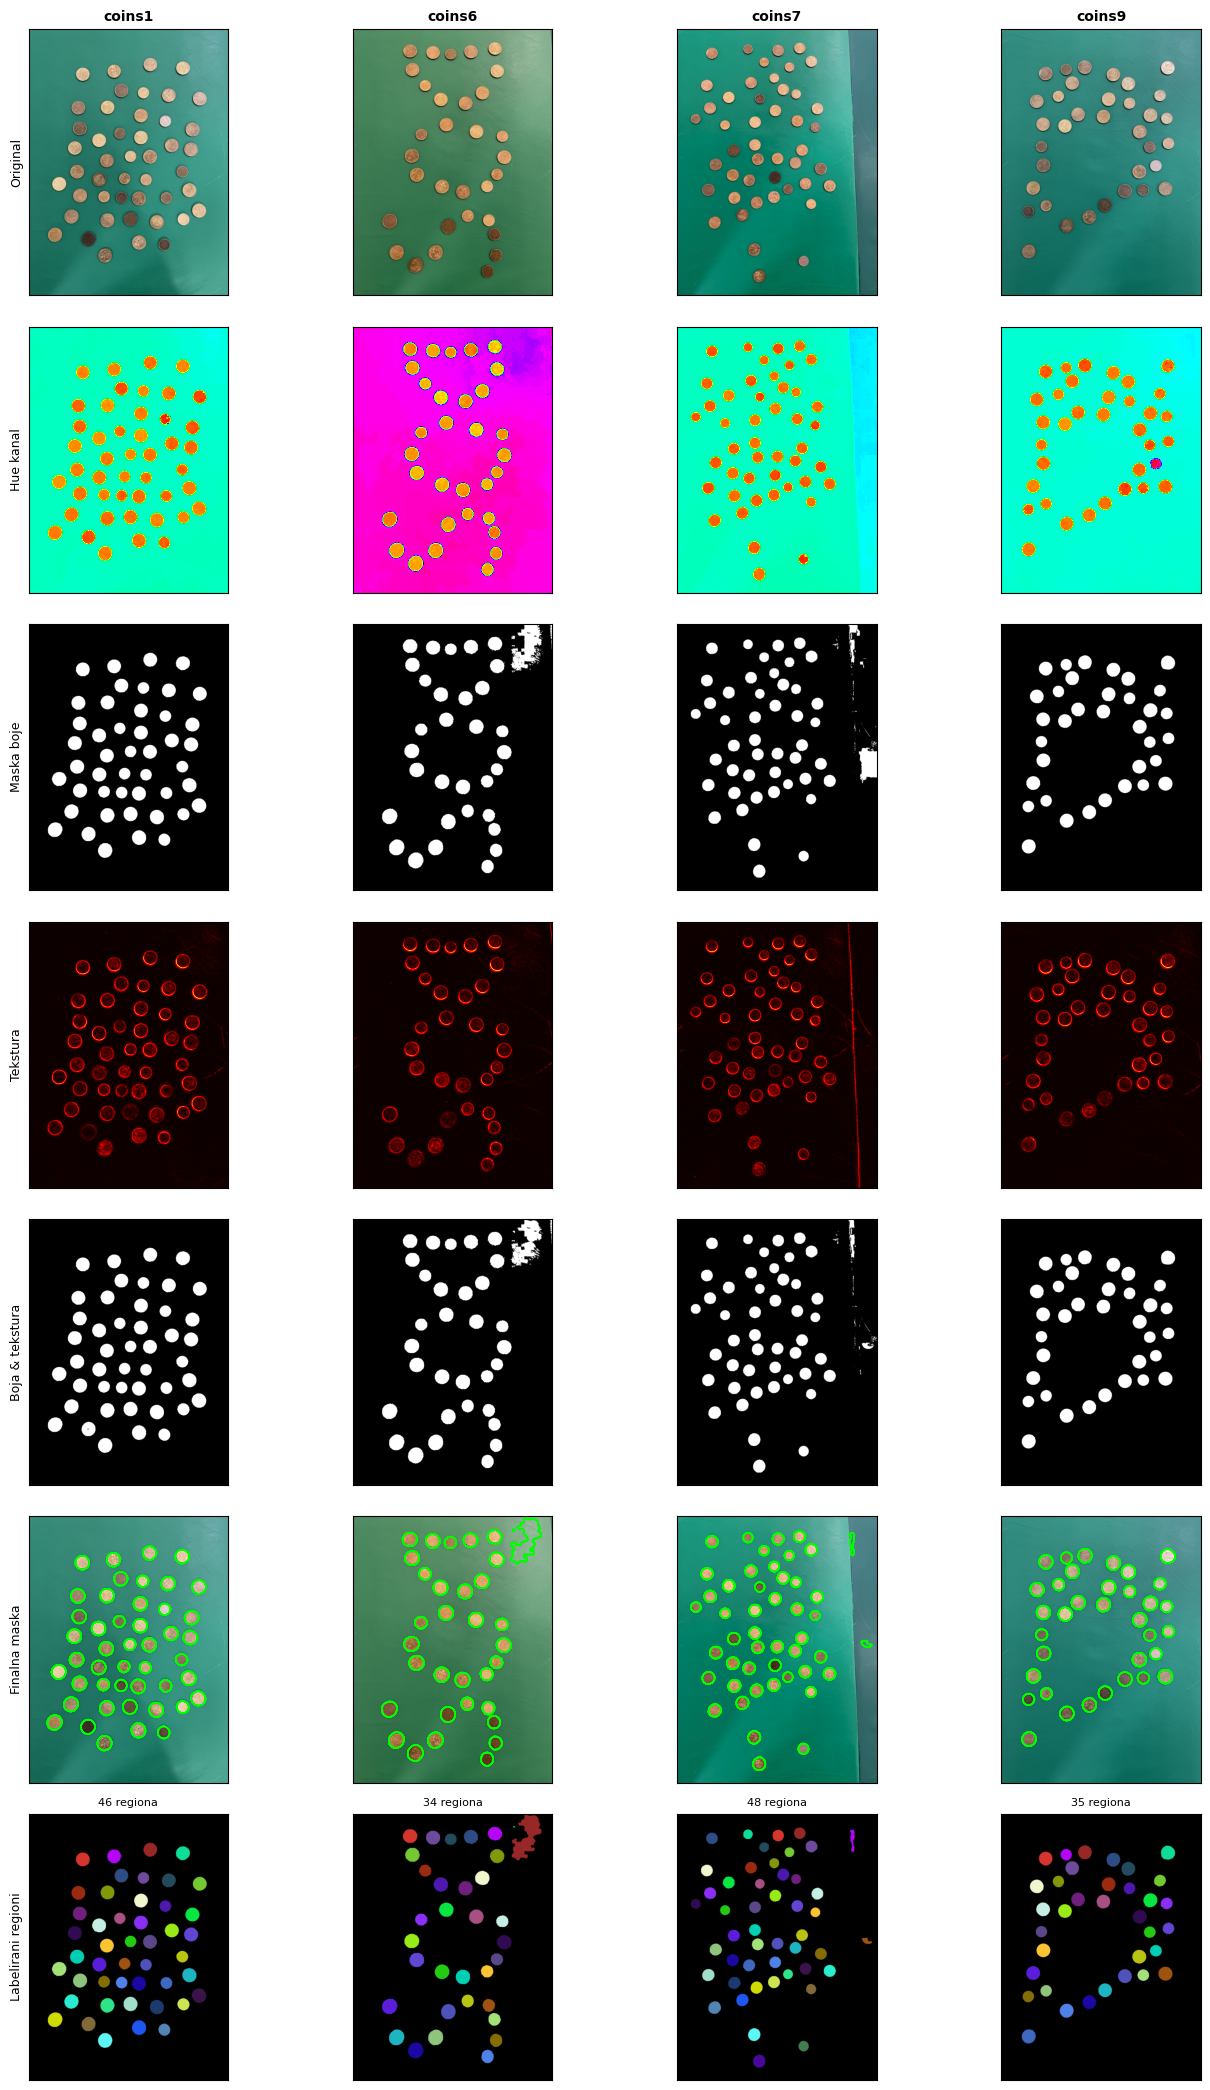

In [7]:
images = ['coins1', 'coins6', 'coins7', 'coins9']
step_names = ['Original', 'Hue kanal', 'Maska boje', 'Tekstura', 'Boja & tekstura', 'Finalna maska', 'Labelirani regioni']

fig, axes = plt.subplots(len(step_names), len(images), figsize=(3.5 * len(images), 3 * len(step_names)))

for j, name in enumerate(images):
    img = io.imread(data_dir + "coins/" + name + ".jpg")
    img_f = util.img_as_float(img) if img.dtype == np.uint8 else img
    mask, steps = coin_mask(img, return_steps=True)
    labeled, num = bw_label(mask)

    axes[0][j].imshow(img_f)
    axes[1][j].imshow(steps['hue'], cmap='hsv')
    axes[2][j].imshow(steps['color_mask'], cmap='gray')
    axes[3][j].imshow(steps['std_dev'], cmap='hot')
    axes[4][j].imshow(steps['combined'], cmap='gray')

    # finalna maska preklopljena na original
    axes[5][j].imshow(img_f)
    axes[5][j].contour(mask, colors='lime', linewidths=1)

    # labelirani regioni - svaki drugom bojom
    label_vis = np.zeros((*mask.shape, 3))
    if num > 0:
        np.random.seed(42)
        colors = np.random.rand(num + 1, 3)
        colors[0] = [0, 0, 0]
        for lbl in range(1, num + 1):
            label_vis[labeled == lbl] = colors[lbl]
    axes[6][j].imshow(label_vis)
    axes[6][j].set_title(f'{num} regiona', fontsize=8)

    axes[0][j].set_title(name, fontsize=10, fontweight='bold')

for k, s_names in enumerate(step_names):
    axes[k][0].set_ylabel(s_names, fontsize=9)

for ax in axes.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
fig.savefig(res_dir + "medjukoraci.png", dpi=130, bbox_inches='tight')
plt.show()

Kao što se vidi na slici međukoraka, kombinacija boje i teksture uspješno eliminiše sjenke i odsjaj koji bi ometali jednostavnu segmentaciju pragom. Kasnije se još eleminišu svi nekružni objekti koje možemo primijetiti na slikama `coins6.jpg` i `coins7.jpg`.

### Drugi dio

U ovom zadatku se od nas traži da od "nule" implemetiramo Canny-jev algoritam.

Canny detekcija ivica je višestepeni algoritam koji se smatra zlatnim standardom za detekciju ivica u digitalnoj obradi slike. Implementacija prati klasičan pristup opisan na predavanjima i sastoji se od pet koraka.

- **Gausovo filtriranje**: Ulazna slika se prvo konvolvira sa 2D Gausovim kernelom standardne devijacije $\sigma$. Veličina kernela se računa kao `ceil(6σ)`, čime se obuhvata 99.7% raspodjele. Gausovo filtriranje je niskopropusni filtar koji potiskuje visokofrekventni šum prije računanja gradijenta, jer bi bez njega i najmanji šum generisao lažne ivice.
- **Računanje gradijenta**: Na filtriranu sliku primjenjuje se Sobelov operator tj. dva $3×3$ kernela za parcijalne izvode po $x$ i $y$ osi. Iz parcijalnih izvoda $Ix$ i $Iy$ računa se magnituda gradijenta $G = \sqrt{Ix^2 + Iy^2}$ i ugao $\theta = arctan2(Iy, Ix)$. Magnituda govori o jačini ivice, a ugao o njenom smjeru.
- **Non-maximum suppression (NMS)**: Cilj ovog koraka je stanjivanje ivica — od širokih oblasti visokog gradijenta zadržavamo samo lokalne maksimume u pravcu gradijenta. Ugao gradijenta se kvantizuje na četiri smjera $(0°, 45°, 90°, 135°)$ i za svaki piksel se provjerava da li je njegova magnituda veća ili jednaka od oba suseda u tom smeru. Ako jeste, piksel se zadržava; u suprotnom se postavlja na nulu.
- **Dvostruko threshold-ovanje**: Pikseli koji su preživjeli NMS klasifikuju se u dvije kategorije na osnovu dva praga. Pikseli sa magnitudom iznad gornjeg praga su jake ivice, a one su pouzdane i sigurno pripadaju ivicama. Pikseli između donjeg i gornjeg praga su slabe ivice, a one su kandidati koji se prihvataju samo ako su povezani sa jakom ivicom.
- **Histerezis**: Polazeći od svih jakih ivica, DFS (depth-first search) pretragom se prolazi kroz 8-susjedstvo. Svaka slaba ivica koja je susjedna jakoj (ili već prihvaćenoj slaboj) ivici se prihvata kao stvarna ivica. Slabe ivice koje nisu povezane ni sa jednom jakom ivicom se odbacuju. Ovim se postiže da se ivice prate duž čitave konture čak i tamo gdje gradijent blago opada.

In [8]:
def canny_edge_detection(img_in, sigma=1.0, low_thresh=0.05, high_thresh=0.15, verbose=False, return_steps=False):
    img = ski.util.img_as_float(img_in)

    if img.ndim == 3:
        img = ski.color.rgb2gray(img)

    # velicina kernela - 6*sigma je dovoljno da pokrije preko 99.7% raspodjele
    k_size = int(np.ceil(6 * sigma))
    if k_size % 2 == 0:
        k_size += 1

    half = k_size // 2
    x = np.arange(-half, half + 1)
    g = np.exp(-x**2 / (2 * sigma**2))
    g = g / g.sum()
    gauss_kernel = np.outer(g, g)

    # gausovo filtriranje za smanjenje suma
    img_smooth = ndi.convolve(img, gauss_kernel, mode='reflect')

    # sobelov operator - parcijalni izvodi po x i y
    Kx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]], dtype=np.float64)

    Ky = np.array([[-1, -2, -1],
                   [ 0,  0,  0],
                   [ 1,  2,  1]], dtype=np.float64)

    Ix = ndi.convolve(img_smooth, Kx, mode='reflect')
    Iy = ndi.convolve(img_smooth, Ky, mode='reflect')

    # magnituda i ugao gradijenta
    G_mag = np.sqrt(Ix**2 + Iy**2)
    G_angle = np.rad2deg(np.arctan2(Iy, Ix))

    # prebacivanje uglova u opseg [0, 180) za kvantizaciju
    angle = G_angle.copy()
    angle[angle < 0] += 180

    # kvantizacija na 4 smjera: 0, 45, 90, 135 (-45)
    q_angle = np.zeros_like(angle)
    q_angle[(angle < 22.5) | (angle >= 157.5)] = 0
    q_angle[(angle >= 22.5) & (angle < 67.5)] = 45
    q_angle[(angle >= 67.5) & (angle < 112.5)] = 90
    q_angle[(angle >= 112.5) & (angle < 157.5)] = -45

    # non-maximum suppression - zadrzavamo samo lokalne maksimume u pravcu gradijenta
    M, N = img.shape
    nms = np.zeros((M, N), dtype=np.float64)

    for i in range(1, M - 1):
        for j in range(1, N - 1):
            mag = G_mag[i, j]
            a = q_angle[i, j]

            if a == 0:
                n1, n2 = G_mag[i, j-1], G_mag[i, j+1]
            elif a == 45:
                n1, n2 = G_mag[i-1, j+1], G_mag[i+1, j-1]
            elif a == 90:
                n1, n2 = G_mag[i-1, j], G_mag[i+1, j]
            else:
                n1, n2 = G_mag[i-1, j-1], G_mag[i+1, j+1]

            # moze i sa > i sa >= jer ja ne vidim neku veliku razliku
            if mag > n1 and mag > n2:
                nms[i, j] = mag

    # dvostruki thresholding
    strong = (nms >= high_thresh).astype(np.uint8)
    weak = ((nms >= low_thresh) & (nms < high_thresh)).astype(np.uint8)

    # histerezis - DFS pretragom povezujemo slabe ivice sa jakim
    result = strong.copy()
    si, sj = np.where(strong == 1)
    stack = list(zip(si, sj))

    susedi = [(-1,-1), (-1,0), (-1,1),
              (0,-1),          (0,1),
              (1,-1),  (1,0),  (1,1)]

    while stack:
        r, c = stack.pop()
        for dr, dc in susedi:
            nr, nc = r + dr, c + dc
            if 0 <= nr < M and 0 <= nc < N:
                if weak[nr, nc] == 1 and result[nr, nc] == 0:
                    result[nr, nc] = 1
                    stack.append((nr, nc))

    # opciono vracanje medjukoraka
    if return_steps:
        koraci = {
            'smooth': img_smooth,
            'G_mag': G_mag,
            'q_angle': q_angle,
            'nms': nms,
            'strong': strong,
            'weak': weak,
        }
        return result, koraci

    if verbose:
        fig, axes = plt.subplots(2, 4, figsize=(16, 7))
        fig.suptitle(f'\u03c3={sigma}, low={low_thresh}, high={high_thresh}', fontsize=11)

        axes[0,0].imshow(img, cmap='gray')
        axes[0,0].set_title('Original')
        axes[0,1].imshow(img_smooth, cmap='gray')
        axes[0,1].set_title(f'Gausovo filtriranje (\u03c3={sigma})')
        axes[0,2].imshow(G_mag, cmap='gray')
        axes[0,2].set_title('Magnituda gradijenta')
        axes[0,3].imshow(q_angle, cmap='hsv')
        axes[0,3].set_title('Kvantizovani uglovi')
        axes[1,0].imshow(nms, cmap='gray')
        axes[1,0].set_title('NMS')
        axes[1,1].imshow(strong, cmap='gray')
        axes[1,1].set_title(f'Jake ivice (\u2265{high_thresh})')
        axes[1,2].imshow(weak, cmap='gray')
        axes[1,2].set_title(f'Slabe ivice ({low_thresh}\u2264x<{high_thresh})')
        axes[1,3].imshow(result, cmap='gray')
        axes[1,3].set_title('Rezultat')

        for ax in axes.flatten():
            ax.axis('off')
        plt.tight_layout()

    return result

Gausov kernel se generiše analitički, računa se 1D Gausova funkcija za dato $\sigma$, normalizuje se da suma bude $1$, a zatim se spoljašnjim proizvodom formira 2D kernel. Konvolucija se vrši sa reflektovanim graničnim uslovima (`mode='reflect'`), čime se izbjegavaju artefakti na ivicama slike.

Za kvantizaciju uglova, $arctan2$ daje vrijednosti u opsegu $[-180°, 180°]$. Negativni uglovi se prvo mapiraju u opseg $[0°, 180°)$ jer su smjerovi $0°$ i $180°$ ekvivalentni (obje strane iste ivice). Zatim se ugao svrstava u jedan od četiri smjera na osnovu opsega: $0°$ za $[0°, 22.5°)$ $\cup$ $[157.5°, 180°)$, $45°$ za $[22.5°, 67.5°)$, $90°$ za $[67.5°, 112.5°)$ i $135°$ za $[112.5°, 157.5°)$.

Histerezis je implementiran iterativno pomoću steka umjesto rekurzije, čime se izbjegava problem prekoračenja dubine rekurzije na velikim slikama.

**Analiza robusnosti**:

Algoritam ima tri parametra: $\sigma$, donji prag i gornji prag. Robusnost zavisi od izbora ovih parametara.
Parametar $\sigma$ kontroliše stepen smooth-ovanja. Za slike sa malo šuma (`lena.tif`), $\sigma = 1.0–1.5$ daje dobre rezultate. Za slike sa puno šuma (`cameraman.tif`), potrebno je veće $\sigma$ $(1.8–2.5)$, ali uz gubitak finih detalja. Algoritam nije robusan na promjenu $\sigma$ u smislu da ne postoji jedna univerzalna vrednost tj. korisnik mora birati $\sigma$ prema nivou šuma u slici.
Pragovi takođe zahtjevaju ručno podešavanje. Gornji prag kontroliše koliko ivica započinje, donji koliko se daleko prostiru. Previsoki pragovi daju nepovezane fragmente, preniski daju lažne ivice od šuma. U praksi se preporučuje odnos gornjeg i donjeg praga 2:1 ili 3:1, ali optimalne apsolutne vrijednosti zavise od slike.

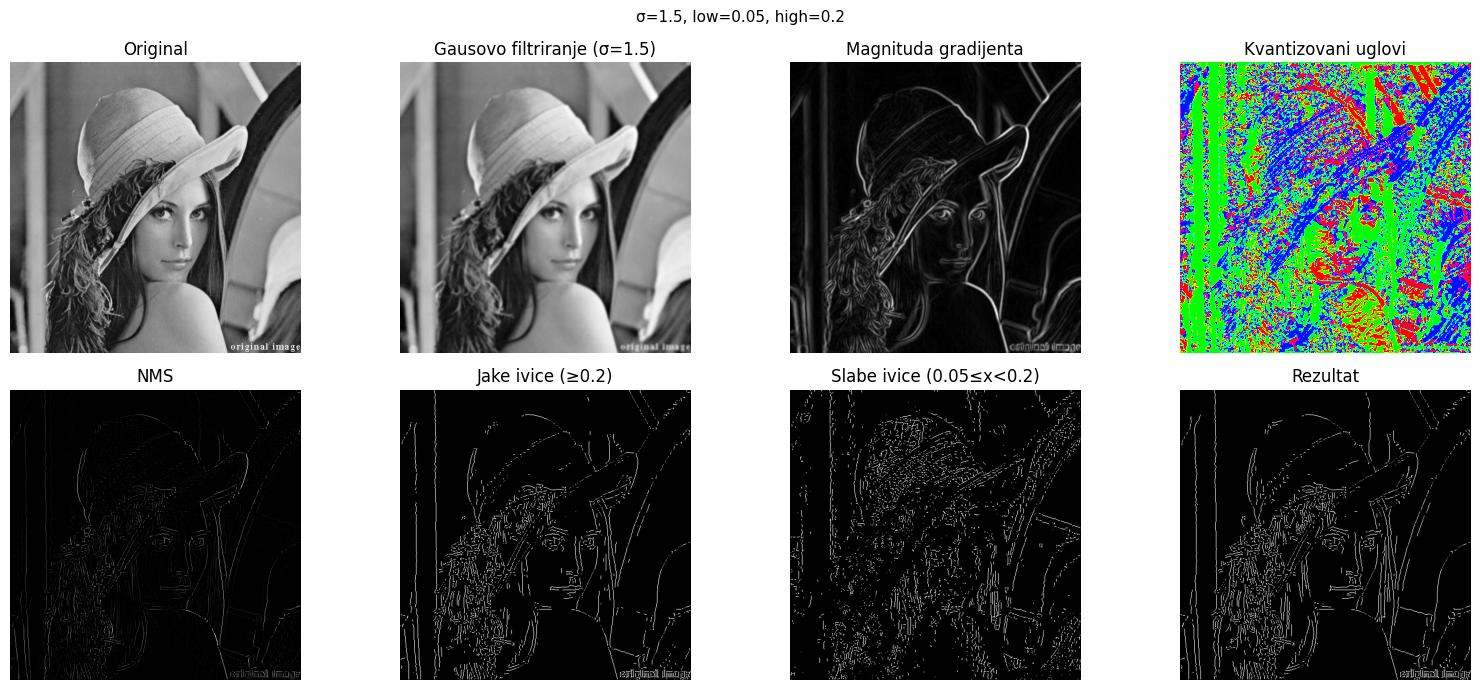

  lena: sigma=1.5, low=0.05, high=0.2


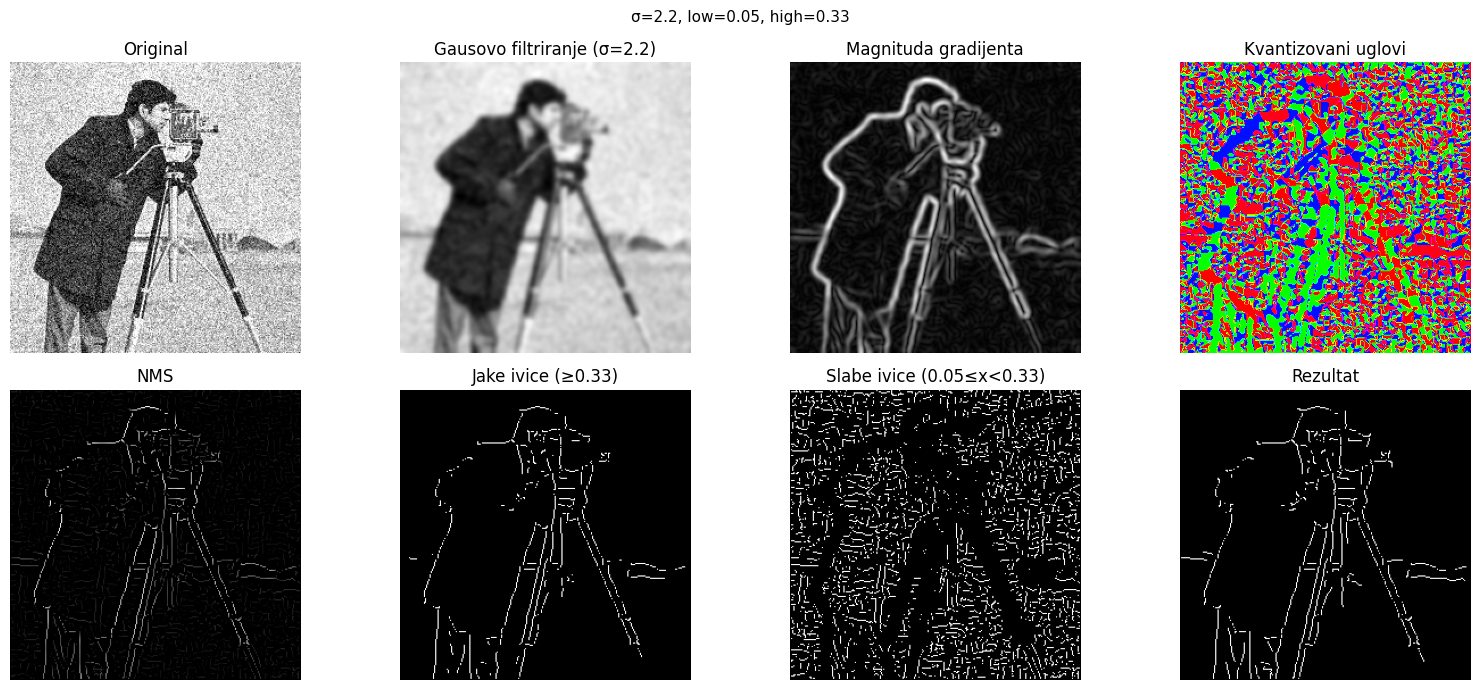

  camerman: sigma=2.2, low=0.05, high=0.33


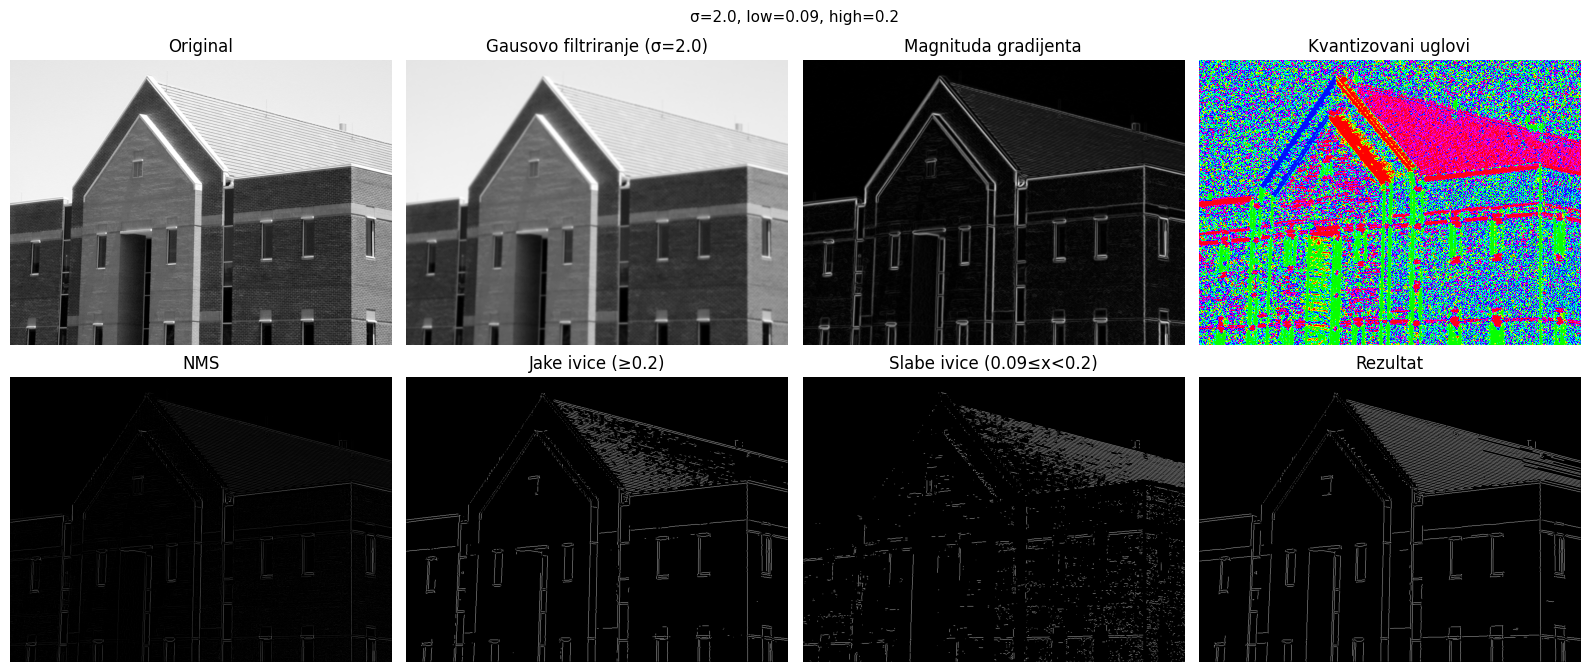

  building: sigma=2.0, low=0.09, high=0.2


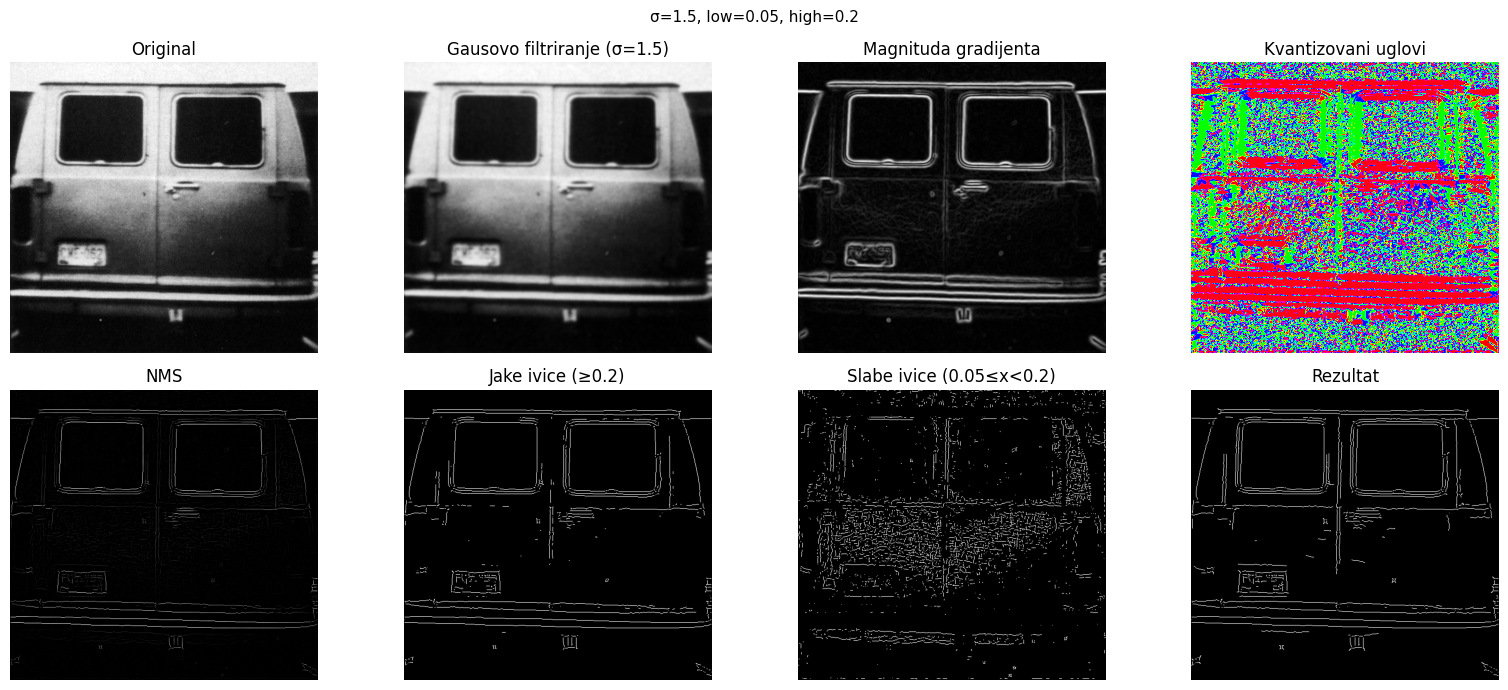

  van: sigma=1.5, low=0.05, high=0.2


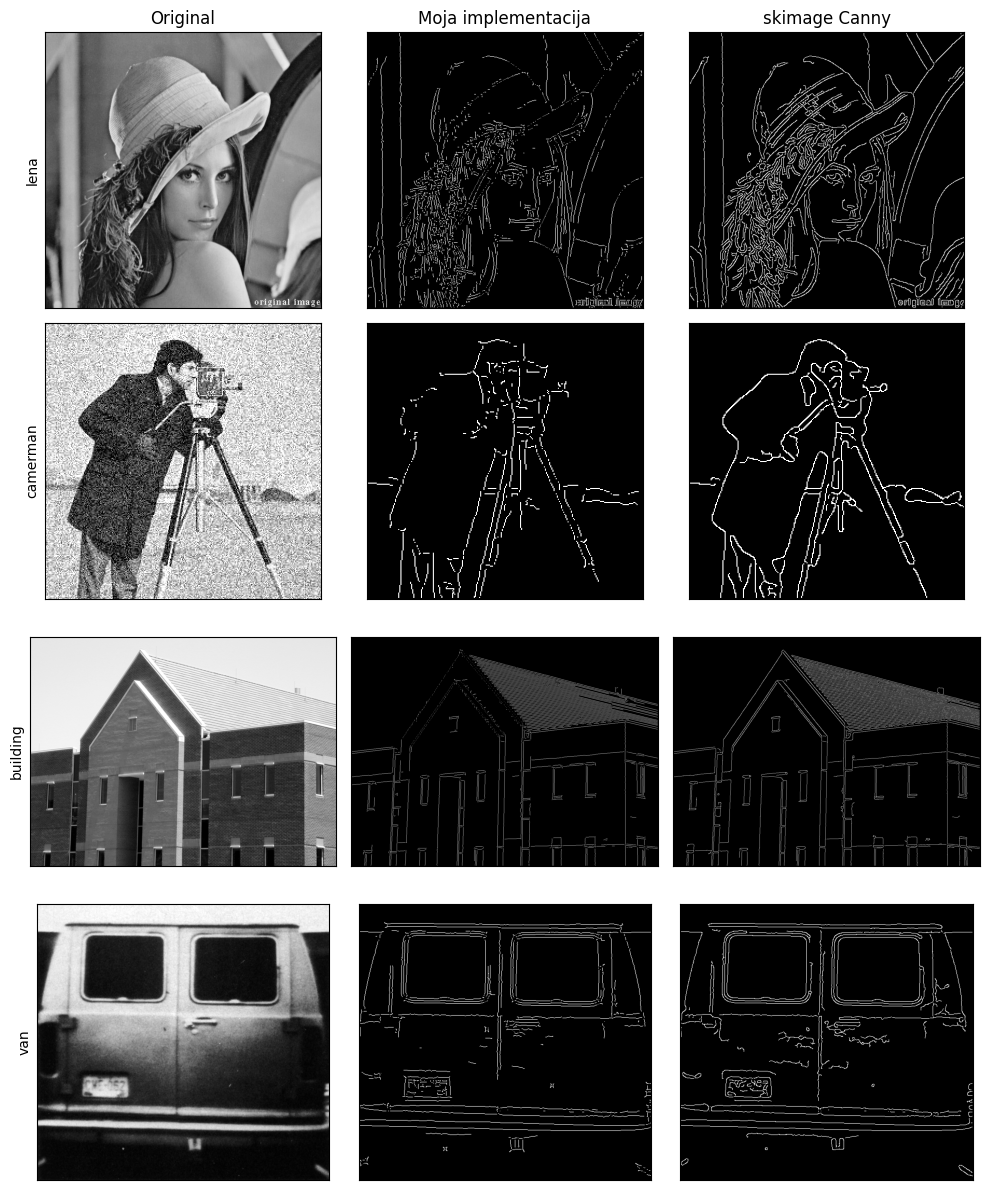

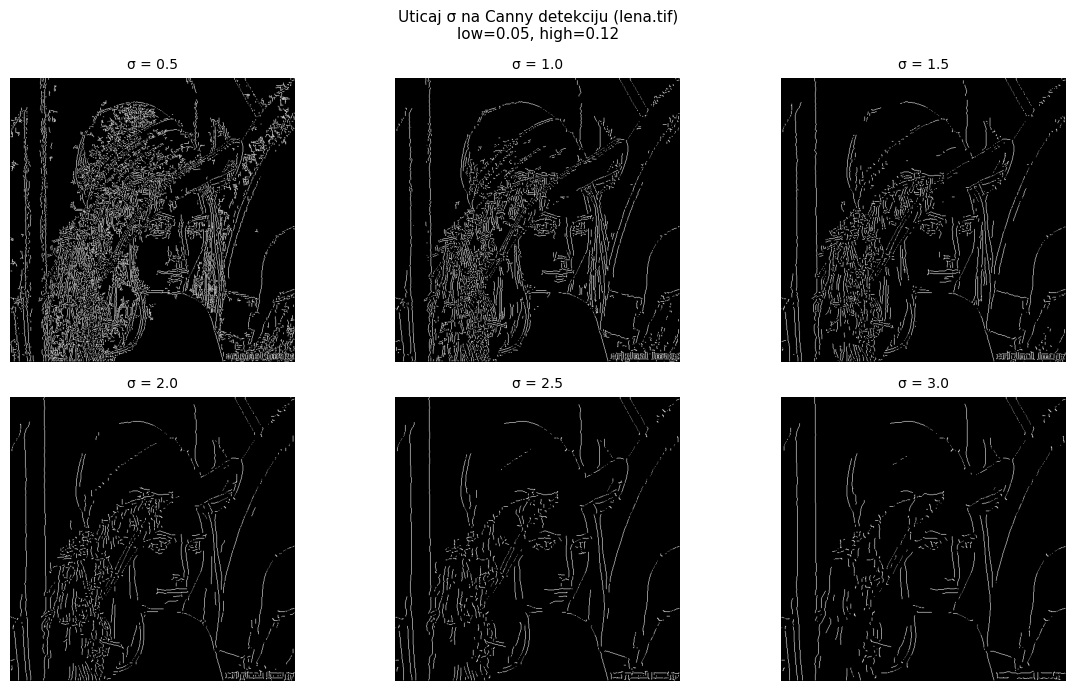

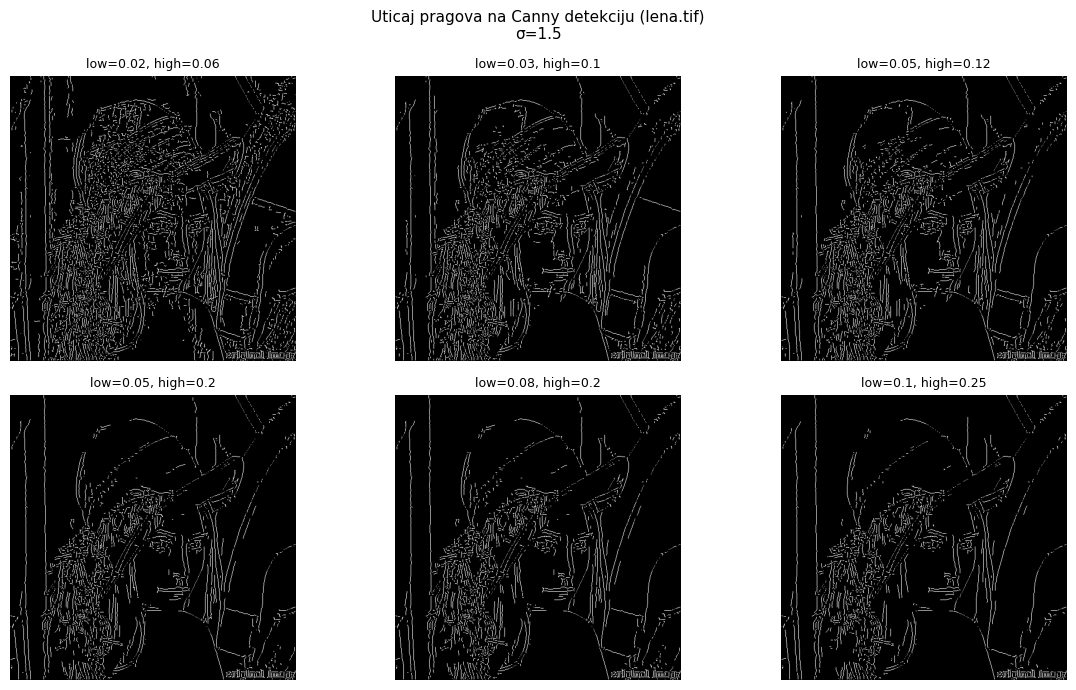

In [9]:
canny_params = {
    'lena':      {'sigma': 1.5, 'low': 0.05, 'high': 0.2},
    'camerman': {'sigma': 2.2, 'low': 0.05, 'high': 0.33},
    'building':     {'sigma': 2.0, 'low': 0.09, 'high': 0.2},
    'van':       {'sigma': 1.5, 'low': 0.05, 'high': 0.2},
}

for name, p in canny_params.items():
    img = io.imread(data_dir + name + ".tif")
    canny_edge_detection(img, p['sigma'], p['low'], p['high'], verbose=True)
    plt.show()
    print(f"  {name}: sigma={p['sigma']}, low={p['low']}, high={p['high']}")


# poredjenje sa skimage Canny funkcijom
from skimage.feature import canny as skimage_canny

fig, axes = plt.subplots(len(canny_params), 3, figsize=(10, 3 * len(canny_params)))

for i, (name, p) in enumerate(canny_params.items()):
    img = io.imread(data_dir + name + ".tif")
    img_gray = ski.color.rgb2gray(ski.util.img_as_float(img)) if img.ndim == 3 else ski.util.img_as_float(img)

    my = canny_edge_detection(img, p['sigma'], p['low'], p['high'])
    sk_res = skimage_canny(img_gray, sigma=p['sigma'], low_threshold=p['low'], high_threshold=p['high'])

    axes[i][0].imshow(img_gray, cmap='gray')
    axes[i][0].set_ylabel(name, fontsize=10)
    axes[i][1].imshow(my, cmap='gray')
    axes[i][2].imshow(sk_res, cmap='gray')

axes[0][0].set_title('Original')
axes[0][1].set_title('Moja implementacija')
axes[0][2].set_title('skimage Canny')

for ax in axes.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


# uticaj sigma na rezultat (lena.tif)

img_lena = io.imread(data_dir + "lena.tif")

sigmas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for k, s in enumerate(sigmas):
    ax = axes.flatten()[k]
    edges = canny_edge_detection(img_lena, sigma=s, low_thresh=0.05, high_thresh=0.2)
    ax.imshow(edges, cmap='gray')
    ax.set_title(f'\u03c3 = {s}', fontsize=10)
    ax.axis('off')

plt.suptitle('Uticaj \u03c3 na Canny detekciju (lena.tif)\nlow=0.05, high=0.12', fontsize=11)
plt.tight_layout()
plt.show()


# uticaj pragova na rezultat (lena.tif)
thresholds = [
    (0.02, 0.06), (0.03, 0.10), (0.05, 0.12),
    (0.05, 0.20), (0.08, 0.20), (0.10, 0.25),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for k, (lo, hi) in enumerate(thresholds):
    ax = axes.flatten()[k]
    edges = canny_edge_detection(img_lena, sigma=1.5, low_thresh=lo, high_thresh=hi)
    ax.imshow(edges, cmap='gray')
    ax.set_title(f'low={lo}, high={hi}', fontsize=9)
    ax.axis('off')

plt.suptitle('Uticaj pragova na Canny detekciju (lena.tif)\n\u03c3=1.5', fontsize=11)
plt.tight_layout()
plt.show()

Parametar $\sigma$ Gausovog filtra direktno kontroliše stepen smooth-ovanja slike prije računanja gradijenta. Gausov kernel sa standardnom devijacijom $\sigma$ djeluje kao niskopropusni filtar koji usrednjava piksele u okolini poluprečnika približno $3\sigma$. Za male vrijednosti $\sigma$ (npr. $0.5$), kernel je uzak i slika se minimalno filtrira, pa šum na slici generiše veliki broj lažnih gradijenata koji se pojavljuju kao lažne ivice u rezultatu. Sa povećanjem $\sigma$ ($1.0 – 1.5$), šum se potiskuje i ivice postaju čistije, dok se sitni detalji još uvijek zadržavaju. Za veće vrijednosti $\sigma$ ($2.0 – 3.0$), filtriranje postaje agresivno, šum je potpuno eliminisan, ali se gube i fini detalji poput teksture kose, crta lica i manjih objekata na slici. Ovo predstavlja fundamentalni kompromis Canny algoritma: i šum i fini detalji su visokofrekventni sadržaj, pa ih niskopropusni filtar ne može razdvojiti. Izbor $\sigma$ zavisi od primjene, za slike sa malo šuma koristi se manja vrijednost, dok je za slike sa puno šuma slike potrebno veće $\sigma$ uz prihvatanje gubitka detalja.

Canny algoritam koristi dva praga za klasifikaciju piksela ivica nakon non-maximum suppression koraka. Gornji prag ($high$) određuje koji pikseli se smatraju jakim ivicama i to su polazne tačke za histerezis pretragu. Donji prag ($low$) određuje koji pikseli se smatraju slabim ivicama i oni se prihvataju samo ako su povezani sa jakom ivicom. Na taj način, gornji prag kontroliše koliko ivica uopšte započinje, a donji prag kontroliše koliko daleko se te ivice prostiru.
Za niske vrijednosti oba praga ($low=0.02$, $high=0.06$), gotovo svaki gradijent prolazi, a rezultat sadrži mnogo lažnih ivica i šuma. Sa umjerenim pragovima ($low=0.05$, $high=0.15$), postiže se dobar balans: jake ivice se pouzdano detektuju, a slabe ivice ih dopunjuju tamo gdje je gradijent nešto slabiji, ali i dalje realan. Ako se na primjer bavimo poređenjem slučajeva sa istim donjim pragom, a različitim gornjim (npr. $low=0.05$ sa $high=0.12$ vs $high=0.20$): veći gornji prag znači manje polaznih tačaka za histerezis, pa ivice postaju kraće i nepovezane, iako je donji prag isti. Za visoke vrijednosti oba praga ($low=0.10$, $high=0.25$), preostaju samo najjači kontrastni prelazi, dok se fini detalji potpuno gube. Odnos između pragova je takođe bitan i bilo bi dobro da je gornji prag bar $2$ ili $3$ puta veći od donjeg.

Poređenjem rezultata sopstvene implementacije sa `skimage.feature.canny` funkcijom, uočava se da skimage daje čistije i potpunije ivice. Razlog leži u nekoliko numeričkih poboljšanja koja skimage koristi u odnosu na osnovni algoritam sa predavanja. 
- Prvo, umjesto odvojenog Gausovog filtriranja i Sobelovog operatora ($3×3$ aproksimacija), skimage računa gradijent konvolucijom sa izvodom Gausove funkcije, što je matematički ekvivalentno, ali numerički preciznije.
- Drugo, pri non-maximum suppression koraku, moja implementacija kvantizuje ugao gradijenta na 4 smjera $(0°, 45°, 90°, 135°)$ i poredi sa dva najbliža susjeda, dok skimage interpolira između susjeda duž tačnog smjera gradijenta, čime se dobijaju tanje i preciznije ivice.
- Treće, skimage interno normalizuje magnitude gradijenta, pa isti pragovi mogu selektovati različite ivice.

Uprkos ovim razlikama, sopstvena implementacija vijerno prati teorijski algoritam sa predavanja: Gausovo filtriranje, Sobelovi parcijalni izvodi, kvantizovana NMS i histerezis sa dvostrukim thresholdingom i daje korektne rezultate na svim test slikama.